# Gap-Filling Pipeline -- Output Analysis Dashboard

This notebook loads the **consolidated report** generated by `gap_filling.py` and provides analysis, visualisation, and interpretation of results across all instruments in the universe.

## Objective

After running `python gap_filling.py --target=ALL`, the pipeline produces a `consolidated_report.csv` in the `results/` directory containing one row per instrument with 24 columns covering reconstruction quality, drift correction, sweep optimisation, and backtesting performance.

This notebook helps you:

1. **Load & inspect** the consolidated results
2. **Understand each column** -- what it measures and how to interpret it
3. **Visualise** cross-sectional performance distributions
4. **Identify** which methods work best for which sectors/market conditions
5. **Diagnose** outliers and edge cases

In [6]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (14, 5), 'font.size': 11})

# Load config.json
SCRIPT_DIR = Path.cwd()
CONFIG_PATH = SCRIPT_DIR / 'config.json'

with open(CONFIG_PATH) as f:
    config = json.load(f)

print('Configuration loaded:')
print(f'  Peers: lookback={config["peers"]["lookback"]}, cluster_thr={config["peers"]["cluster_thr"]}, '
      f'max_peers={config["peers"]["max_peers"]}')
print(f'  Distress: depth={config["distress"]["dist_depth"]}, length={config["distress"]["dist_length"]}')
print(f'  Sweep: lookback_grid={config["sweep"]["lookback_grid"]}, threshold_grid={config["sweep"]["threshold_grid"]}')
print(f'  Models: elastic_net(l1={config["models"]["elastic_net"]["l1_ratio"]}), '
      f'gpr(kernel={config["models"]["gpr"]["kernel_type"]})')
print(f'  Data: n_days={config["data"]["n_days"]}, min_peer_coverage={config["data"]["min_peer_coverage"]}')

# Load consolidated report from config path
result_path_env = config['paths']['result_path_env_var']
result_path_default = config['paths']['result_path_default']
import os
RESULT_DIR = Path(os.environ.get(result_path_env, SCRIPT_DIR / result_path_default))
consolidated_path = RESULT_DIR / 'consolidated_report.csv'

if not consolidated_path.exists():
    print(f'\nWarning: Consolidated report not found at {consolidated_path}')
    print('Run `python gap_filling.py --target ALL` first.')
    df = pd.DataFrame()
else:
    df = pd.read_csv(consolidated_path)
    print(f'\nLoaded {len(df):,} rows x {len(df.columns)} columns from {consolidated_path}')

df.head(3)

Configuration loaded:
  Peers: lookback=80, cluster_thr=0.35, max_peers=10
  Distress: depth=0.35, length=30
  Sweep: lookback_grid=[40, 60, 80, 120], threshold_grid=[0.25, 0.35, 0.45, 0.55]
  Models: elastic_net(l1=0.5), gpr(kernel=rbf)
  Data: n_days=500, min_peer_coverage=0.85

Loaded 503 rows x 24 columns from /Users/yevgeniy/Development/Projects/FinancialEngineering/quant-finance/qf/timeseries/results/consolidated_report.csv


,Target,Sector,Best_Method,RMSE,MAE,Return_Corr,N_Methods,N_Peers,Distress_Start,Distress_End,...,Enhanced_Sweep_THR,Enhanced_Sweep_MP,Enhanced_Sweep_RMSE,Enhanced_Sweep_MAPE,Enhanced_Sweep_DirAcc,True_Return,True_Sharpe,Observed_Return,Observed_Sharpe,Output_Dir
0,AMCR,Materials,Static Proxy+OLS,0.133546,0.110717,0.022189,8,25,2024-12-11,2025-01-27,...,NaN,NaN,NaN,NaN,NaN,0.263075,0.823134,-0.162888,-0.384952,/Users/yevgeniy/Development/Projects/Financial...
1,KVUE,Consumer Staples,Dynamic Proxy+OLS,0.235365,0.182563,0.280689,7,25,2024-11-20,2025-01-03,...,NaN,NaN,NaN,NaN,NaN,0.197332,0.562651,-0.134739,-0.227873,/Users/yevgeniy/Development/Projects/Financial...
2,HBAN,Financials,ML Proxy+Opt (Best Sweep),0.280391,0.222822,0.219514,8,25,2024-12-11,2025-01-27,...,NaN,NaN,NaN,NaN,NaN,0.480814,1.069083,-0.059968,-0.026578,/Users/yevgeniy/Development/Projects/Financial...


Best predicted company per sector (lowest RMSE):
Sector                   Target    Best Method                            RMSE     MAE Ret Corr  Peers
--------------------------------------------------------------------------------------------------------------
Communication Services   T         ML Proxy+Opt (Best Sweep)             0.415   0.327   -0.031     21
Consumer Discretionary   F         GP-RBF                                0.318   0.276    0.075     25
Consumer Staples         KVUE      Dynamic Proxy+OLS                     0.235   0.183    0.281     25
Energy                   KMI       Static Proxy+OLS                      0.672   0.470    0.017     21
Financials               HBAN      ML Proxy+Opt (Best Sweep)             0.280   0.223    0.220     25
Health Care              BAX       ML Proxy+Opt (Best Sweep)             0.533   0.377    0.147     25
Industrials              CSX       ML Proxy+Opt (Best Sweep)             0.515   0.424   -0.125     25
Information Tech

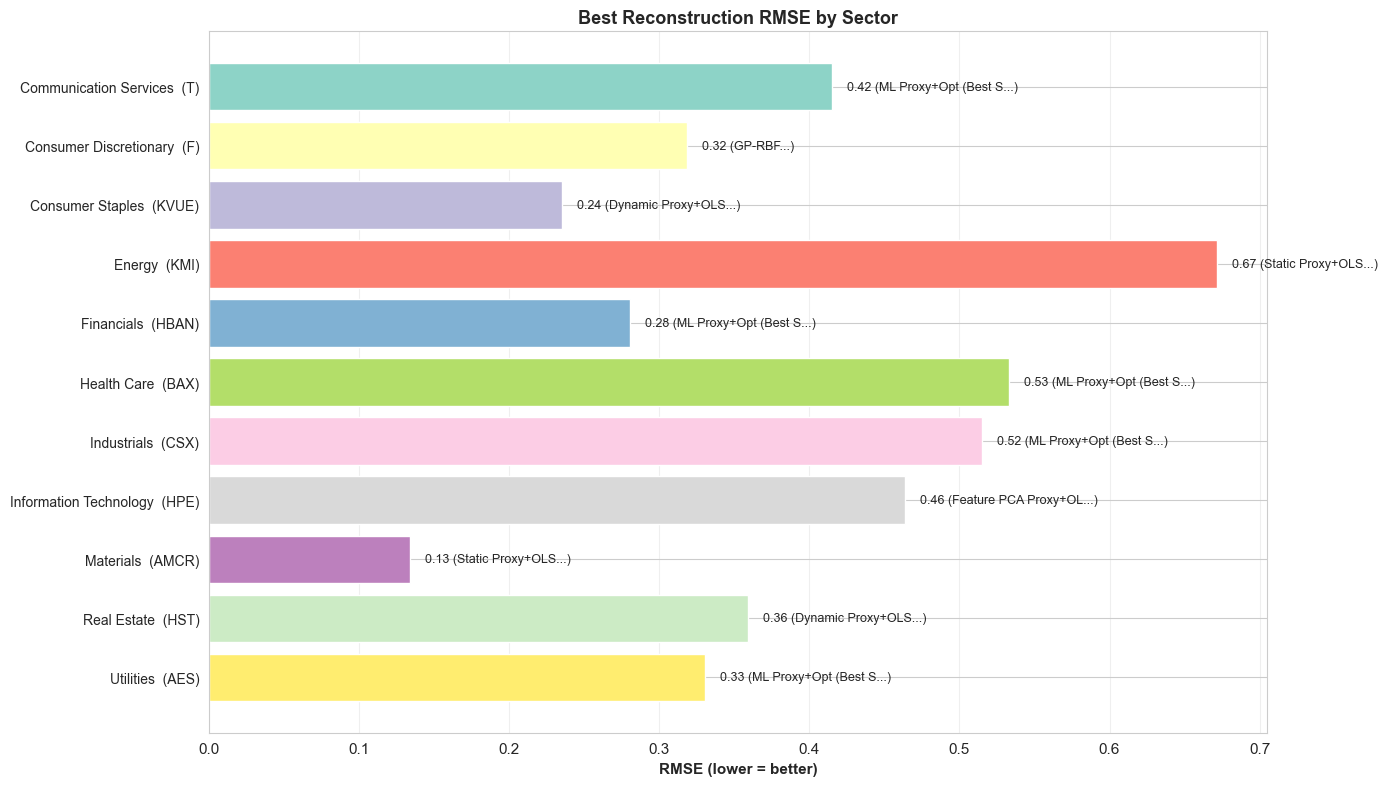

In [7]:
# Analysis 1: Best predicted company for each sector (by RMSE)
if not df.empty:
    best_per_sector = df.loc[df.groupby('Sector')['RMSE'].idxmin()].copy()
    best_per_sector = best_per_sector[['Sector', 'Target', 'Best_Method', 'RMSE', 'MAE',
                                        'Return_Corr', 'N_Peers']].sort_values('Sector').reset_index(drop=True)
    
    print('Best predicted company per sector (lowest RMSE):')
    print('=' * 110)
    print(f'{"Sector":<25}{"Target":<10}{"Best Method":<35}{"RMSE":>8}{"MAE":>8}{"Ret Corr":>9}{"Peers":>7}')
    print('-' * 110)
    for _, r in best_per_sector.iterrows():
        print(f'{r["Sector"]:<25}{r["Target"]:<10}{r["Best_Method"]:<35}{r["RMSE"]:>8.3f}'
              f'{r["MAE"]:>8.3f}{r["Return_Corr"]:>9.3f}{r["N_Peers"]:>7}')
    print('=' * 110)

    # Visualise below the table
    fig, ax = plt.subplots(figsize=(14, 8))
    colors = plt.cm.Set3(np.linspace(0, 1, len(best_per_sector)))
    bars = ax.barh(range(len(best_per_sector)), best_per_sector['RMSE'].values, color=colors, edgecolor='white')
    ax.set_yticks(range(len(best_per_sector)))
    ax.set_yticklabels([f'{r["Sector"]}  ({r["Target"]})' for _, r in best_per_sector.iterrows()], fontsize=10)
    ax.set_xlabel('RMSE (lower = better)', fontweight='bold', fontsize=11)
    ax.set_title('Best Reconstruction RMSE by Sector', fontweight='bold', fontsize=13)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    for i, (_, r) in enumerate(best_per_sector.iterrows()):
        ax.text(r['RMSE'] + 0.01, i, f'{r["RMSE"]:.2f} ({r["Best_Method"][:20]}...)',
                va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('No data loaded. Run the setup cell first.')

## Column Reference -- What Each Metric Means

The consolidated report contains 24 columns organised into logical groups. Below is a detailed explanation of each column, its interpretation, and typical ranges.

---

### Identification Columns

| Column | Type | Description | Example |
|--------|------|-------------|---------|
| **Target** | `str` | Ticker symbol of the instrument being reconstructed | `MSFT`, `AAPL`, `JPM` |
| **Sector** | `str` | GICS sector classification from the instrument catalog | `Information Technology`, `Financials` |
| **Output_Dir** | `str` | Full path to the per-target output folder containing plots, CSVs, and the report | `.../results/msft/` |

---

### Best Method & Quality Metrics

| Column | Type | Description | Interpretation |
|--------|------|-------------|----------------|
| **Best_Method** | `str` | Name of the reconstruction method that achieved the lowest RMSE for this target (simple fill methods excluded) | e.g. `Elastic Net+CV`, `Static Proxy+OLS`, `ML Proxy+Opt (Best Sweep)` |
| **RMSE** | `float` | Root Mean Squared Error -- the standard deviation of prediction errors (in price units) over the distress window | Lower = better. Compare across targets carefully -- varies with price level. |
| **MAE** | `float` | Mean Absolute Error -- the average absolute difference between reconstructed and true prices | Lower = better. Less sensitive to outliers than RMSE. |
| **Return_Corr** | `float` | Correlation between the reconstructed *returns* and the true *returns* within the distress window | Higher = better (max 1.0). Measures directional accuracy. Negative values mean the reconstruction moves opposite to the true path. |
| **N_Methods** | `int` | Number of reconstruction methods that successfully completed for this target (out of all attempted) | Typically 7-10. Lower values indicate methods that crashed due to data issues. |
| **N_Peers** | `int` | Number of same-sector peer candidates used by the reconstruction models | Typically 5-25. Set by `--max-peers` CLI argument. |

**How to read RMSE/MAE:**
```
RMSE = 2.50 means "the typical reconstruction error is about $2.50 per share"
MAE  = 1.80 means "on average the reconstructed price is off by $1.80"
```

**How to read Return_Corr:**
```
Return_Corr = 0.85 -> the reconstructed daily returns closely track true returns
Return_Corr = 0.10 -> the reconstruction captures almost no directional signal
Return_Corr = -0.30 -> the reconstruction moves opposite to the true price
```

---

### Distress Window

| Column | Type | Description | Interpretation |
|--------|------|-------------|----------------|
| **Distress_Start** | `str` | Start date of the injected distress window (YYYY-MM-DD) | Determined by `dist_start = max(40, 0.60 x n_days)` |
| **Distress_End** | `str` | End date of the injected distress window (YYYY-MM-DD) | Determined by `dist_end = dist_start + dist_length` |

The distress window is where a sinusoidal corruption was applied to simulate a crisis period. All reconstruction methods compete to fill this gap.

---

### Sweep Optimisation Results

These columns are populated when `--sweep` is enabled (default). They record the best hyperparameters found by the ML Proxy grid search over `LOOKBACK` x `CLUSTER_THR`.

| Column | Description | Interpretation |
|--------|-------------|----------------|
| **Sweep_Best_LB** | Best lookback window (trading days) found by the sweep | Grid: [40, 60, 80, 120]. Higher = more training data. |
| **Sweep_Best_THR** | Best cluster threshold found by the sweep | Grid: [0.25, 0.35, 0.45, 0.55]. Higher = larger peer clusters. |
| **Sweep_Best_RMSE** | RMSE achieved by the best sweep parameter combination | Should be <= the default ML Proxy RMSE. |

**Interpretation guide:**
```
Sweep_Best_LB = 40  -> short lookback works best (relationships change fast)
Sweep_Best_LB = 120 -> long lookback works best (stable relationships)

Sweep_Best_THR = 0.25 -> tight clustering (fewer, more similar peers)
Sweep_Best_THR = 0.55 -> loose clustering (more diverse peers)
```

---

### Enhanced Sweep (Multi-Objective) Results

These columns are populated by the enhanced random-search sweep (`ml_proxy_enhanced_optimisation`) which uses 50 random parameter combinations, 80/20 out-of-sample validation, and multi-objective composite scoring.

| Column | Description | Interpretation |
|--------|-------------|----------------|
| **Enhanced_Sweep_LB** | Best lookback from multi-objective optimisation | Sampled uniformly from [30, 120] |
| **Enhanced_Sweep_THR** | Best cluster threshold | Sampled uniformly from [0.20, 0.60] |
| **Enhanced_Sweep_MP** | Best max peers | Sampled uniformly from [3, 10] |
| **Enhanced_Sweep_RMSE** | Out-of-sample RMSE on the test split (last 20% of distress window) | Lower = better. Honest estimate of generalisation error. |
| **Enhanced_Sweep_MAPE** | Mean Absolute Percentage Error (out-of-sample) | Lower = better. Useful for comparing across stocks with different price levels. |
| **Enhanced_Sweep_DirAcc** | Directional Accuracy -- fraction of days where predicted return sign matches true return sign (out-of-sample) | Higher = better (max 1.0). 0.50 = random guess. |

**Why these might be NaN:**
If the enhanced sweep failed (e.g., too few valid parameter combinations), these columns will be `NaN`. This is more common for targets with very short pre-distress windows.

---

### Backtesting Results

After reconstruction, a mean-reversion trading strategy is backtested on each reconstructed price series. The strategy goes long when the price is below its rolling moving average by a threshold, and flat otherwise.

| Column | Description | Interpretation |
|--------|-------------|----------------|
| **True_Return** | Total return of the strategy on the TRUE (uncorrupted) price path | Higher = better. The "ideal" scenario -- what the strategy would have earned with perfect data. |
| **True_Sharpe** | Sharpe ratio of the strategy on the TRUE price path | Higher = better (>1.0 = good). Risk-adjusted return. |
| **Observed_Return** | Total return of the strategy on the OBSERVED (corrupted) price path | Represents the naive approach -- trading on corrupted data. May be negative even when True_Return is positive. |
| **Observed_Sharpe** | Sharpe ratio on the observed (corrupted) path | Often negative when True_Sharpe is positive -- the corruption destroys the strategy. |

**What to look for:**
```
True_Return > 0 and Observed_Return < 0
-> The corruption made a profitable strategy look unprofitable.
  This is exactly the kind of data error this pipeline is designed to fix.

True_Return ~ Observed_Return and both > 0
-> The distress had little impact on this stock's tradability.
```

---

### Summary Statistics Reference

| Metric | Range | Target | Meaning |
|--------|-------|--------|---------|
| RMSE | 0 to inf (price-dependent) | Lower | Typical price prediction error |
| MAE | 0 to inf (price-dependent) | Lower | Average absolute prediction error |
| Return Corr | -1.0 to 1.0 | Higher (>0.3) | Directional accuracy of returns |
| Sweep RMSE | 0 to inf | Lower | Best possible ML Proxy error |
| Enhanced RMSE | 0 to inf | Lower | Out-of-sample ML Proxy error |
| Enhanced MAPE | 0% to inf | Lower (<10%) | Percentage error (price-independent) |
| Enhanced DirAcc | 0.0 to 1.0 | Higher (>0.5) | Return sign accuracy |
| True Sharpe | -inf to inf | Higher (>0.5) | Risk-adjusted backtest return |
| Observed Sharpe | -inf to inf | Higher | Naive strategy performance |

---

### Pro Tips for Analysis

1. **Compare RMSE across sectors** -- some sectors (e.g., Financials) may be easier to reconstruct than others (e.g., Technology) due to peer homogeneity.

2. **Look for `Return_Corr < 0`** -- these are cases where the reconstruction systematically moves opposite to the true price. Investigate why.

3. **Check `Sweep_Best_LB` patterns** -- if most stocks prefer short lookbacks (40), the market regime is changing rapidly. If most prefer long (120), relationships are stable.

4. **`Enhanced_Sweep_MAPE` > 10%** may indicate a particularly hard-to-reconstruct stock -- check its individual report and plots.

5. **Compare `True_Sharpe` vs `Observed_Sharpe`** -- the gap measures how much value the reconstruction pipeline adds for trading applications.

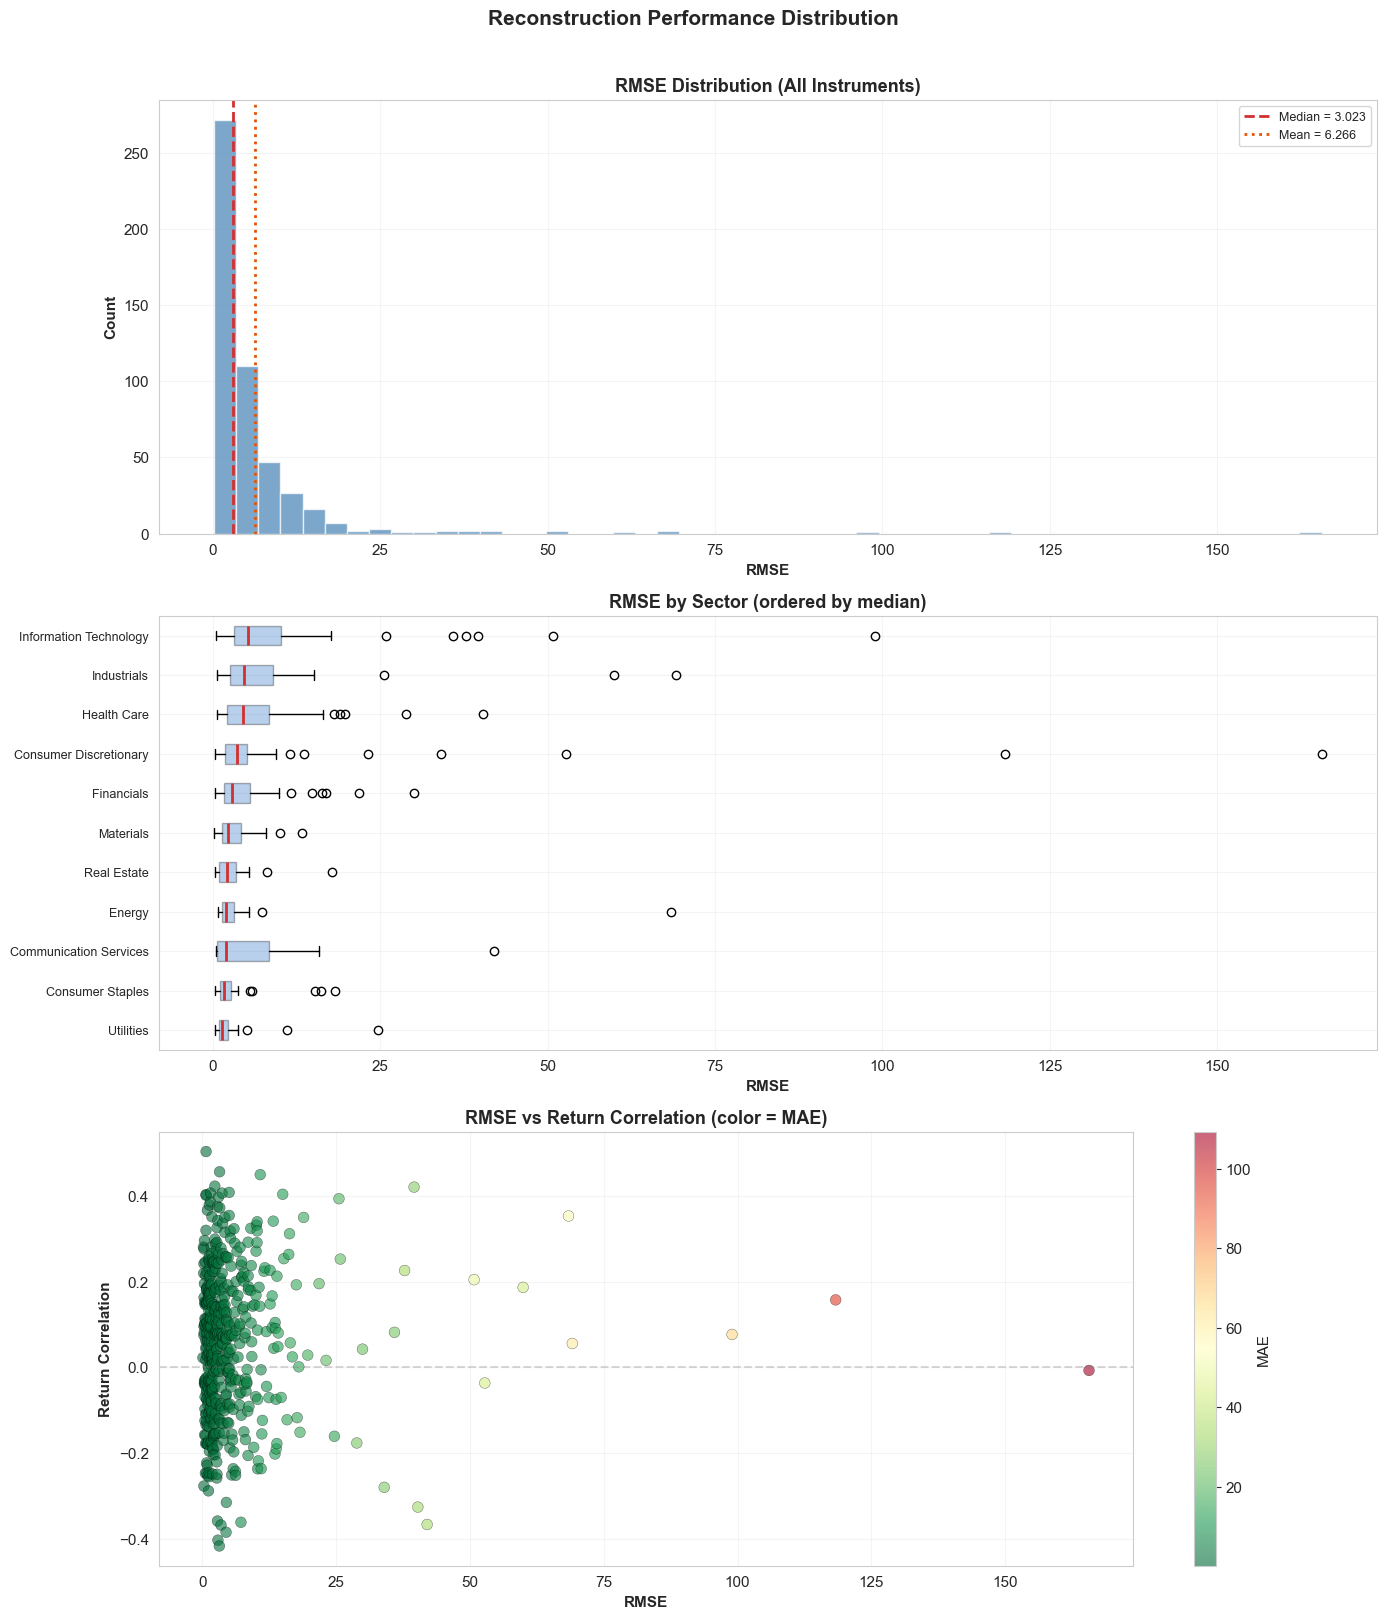

RMSE summary:
  Mean=6.266  Median=3.023  Std=12.644
  Min=0.134  Max=165.661
  Return Corr > 0: 312/503 (62.0%)


In [8]:
# Analysis 2: RMSE distribution across all instruments
if not df.empty:
    fig, axes = plt.subplots(3, 1, figsize=(14, 16))

    # Panel A: RMSE histogram with KDE
    ax = axes[0]
    ax.hist(df['RMSE'].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(df['RMSE'].median(), color='#D32F2F', ls='--', lw=2,
               label=f'Median = {df["RMSE"].median():.3f}')
    ax.axvline(df['RMSE'].mean(), color='#E65100', ls=':', lw=2,
               label=f'Mean = {df["RMSE"].mean():.3f}')
    ax.set_title('RMSE Distribution (All Instruments)', fontweight='bold', fontsize=13)
    ax.set_xlabel('RMSE', fontweight='bold'); ax.set_ylabel('Count', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.2)

    # Panel B: RMSE by sector (box plot)
    ax = axes[1]
    sector_order = df.groupby('Sector')['RMSE'].median().sort_values().index
    box_data = [df[df['Sector'] == s]['RMSE'].dropna().values for s in sector_order]
    bp = ax.boxplot(box_data, patch_artist=True, vert=False,
                    medianprops=dict(color='#D32F2F', linewidth=2, zorder=5))
    for patch, s in zip(bp['boxes'], sector_order):
        patch.set_facecolor('#1565C0'); patch.set_alpha(0.3)
    ax.set_yticks(range(1, len(sector_order) + 1))
    ax.set_yticklabels(sector_order, fontsize=9)
    ax.set_title('RMSE by Sector (ordered by median)', fontweight='bold', fontsize=13)
    ax.set_xlabel('RMSE', fontweight='bold'); ax.grid(alpha=0.2)

    # Panel C: RMSE vs Return Correlation scatter
    ax = axes[2]
    scatter = ax.scatter(df['RMSE'], df['Return_Corr'], c=df['MAE'],
                         cmap='RdYlGn_r', s=60, alpha=0.6, edgecolors='black', linewidth=0.3)
    ax.set_xlabel('RMSE', fontweight='bold'); ax.set_ylabel('Return Correlation', fontweight='bold')
    ax.set_title('RMSE vs Return Correlation (color = MAE)', fontweight='bold', fontsize=13)
    ax.axhline(0, color='gray', ls='--', alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='MAE')
    ax.grid(alpha=0.2)

    plt.suptitle('Reconstruction Performance Distribution', fontweight='bold', fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()

    # Summary stats
    print('RMSE summary:')
    print(f'  Mean={df["RMSE"].mean():.3f}  Median={df["RMSE"].median():.3f}  Std={df["RMSE"].std():.3f}')
    print(f'  Min={df["RMSE"].min():.3f}  Max={df["RMSE"].max():.3f}')
    print(f'  Return Corr > 0: {(df["Return_Corr"] > 0).sum()}/{len(df)} '
          f'({(df["Return_Corr"] > 0).mean()*100:.1f}%)')
else:
    print('No data loaded.')

Dominant reconstruction method per sector:
Sector                   Best Method                     Count    Pct  Median RMSE                 Top 3 Methods
----------------------------------------------------------------------------------------------------
Communication Services   ML Sweep                           13    57%        0.640ML Proxy+Opt (Best Sweep) (13), Elastic Net+CV (3), GP-RBF (3)
Consumer Discretionary   ML Sweep                           22    43%        2.905ML Proxy+Opt (Best Sweep) (22), Elastic Net+CV (8), GP-RBF (6)
Consumer Staples         ML Sweep                           25    66%        1.683ML Proxy+Opt (Best Sweep) (25), Dynamic Proxy+OLS (5), Static Proxy+OLS (4)
Energy                   ML Sweep                           12    52%        1.482ML Proxy+Opt (Best Sweep) (12), Dynamic Proxy+OLS (5), Static Proxy+OLS (3)
Financials               ML Sweep                           42    58%        2.600ML Proxy+Opt (Best Sweep) (42), Dynamic Proxy+OLS (7), 

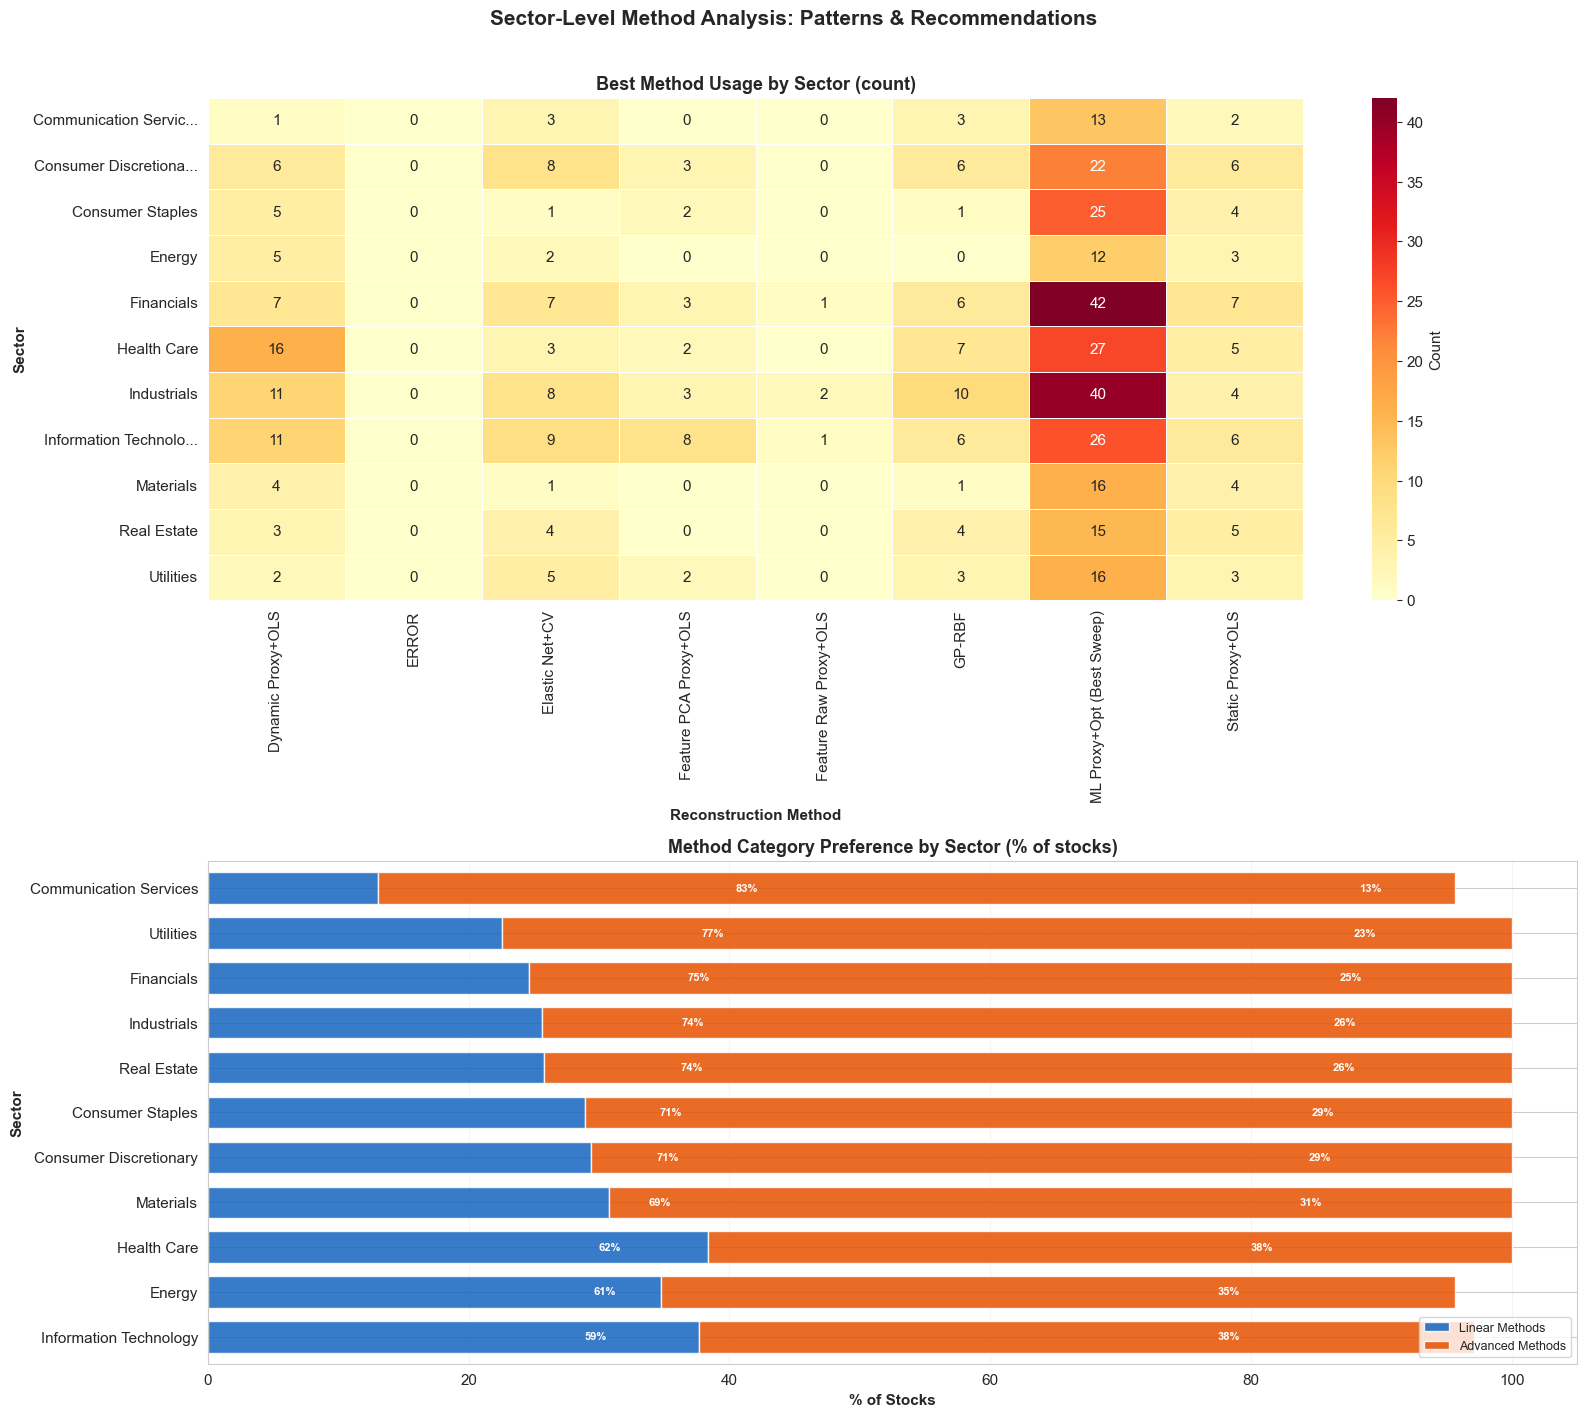


Key findings:
  Communication Services: 23 stocks, prefers advanced methods (ML Proxy+Opt (Best Sweep)), mean RMSE=5.668
  Consumer Discretionary: 51 stocks, prefers advanced methods (ML Proxy+Opt (Best Sweep)), mean RMSE=11.025
  Consumer Staples: 38 stocks, prefers advanced methods (ML Proxy+Opt (Best Sweep)), mean RMSE=3.027
  Energy: 23 stocks, prefers advanced methods (ML Proxy+Opt (Best Sweep)), mean RMSE=5.377
  Financials: 73 stocks, prefers advanced methods (ML Proxy+Opt (Best Sweep)), mean RMSE=4.658
  Health Care: 60 stocks, prefers advanced methods (ML Proxy+Opt (Best Sweep)), mean RMSE=6.702
  Industrials: 78 stocks, prefers advanced methods (ML Proxy+Opt (Best Sweep)), mean RMSE=7.283
  Information Technology: 69 stocks, prefers advanced methods (ML Proxy+Opt (Best Sweep)), mean RMSE=9.598
  Materials: 26 stocks, prefers advanced methods (ML Proxy+Opt (Best Sweep)), mean RMSE=3.326
  Real Estate: 31 stocks, prefers advanced methods (ML Proxy+Opt (Best Sweep)), mean RMSE=

In [9]:
# Analysis 3: Is there a pattern in which method works best per sector?
if not df.empty:
    # Count of best methods per sector
    method_by_sector = df.pivot_table(
        index='Sector', columns='Best_Method', values='RMSE', aggfunc='count', fill_value=0)
    
    def short_name(m):
        replacements = {
            'Static Proxy+OLS': 'Static+OLS',
            'Dynamic Proxy+OLS': 'Dynamic+OLS',
            'Elastic Net+CV': 'ElasticNet+CV',
            'Feature Raw Proxy+OLS': 'FeatRaw+OLS',
            'Feature PCA Proxy+OLS': 'FeatPCA+OLS',
            'GP-RBF': 'GP-RBF',
            'ML Proxy+Opt (Best Sweep)': 'ML Sweep',
            'ML Proxy+Enhanced (Multi-Obj)': 'ML Enhanced',
        }
        return replacements.get(m, m[:18])
    
    # Show top method per sector with count and median RMSE
    print('Dominant reconstruction method per sector:')
    print('=' * 100)
    print(f'{"Sector":<25}{"Best Method":<30}{"Count":>7}{"Pct":>7}{"Median RMSE":>13}{"Top 3 Methods":>30}')
    print('-' * 100)
    
    sector_summary = []
    for sector in sorted(df['Sector'].unique()):
        sector_df = df[df['Sector'] == sector]
        top_method = sector_df['Best_Method'].value_counts().index[0]
        top_count = sector_df['Best_Method'].value_counts().iloc[0]
        top_pct = top_count / len(sector_df) * 100
        median_rmse = sector_df[sector_df['Best_Method'] == top_method]['RMSE'].median()
        top3 = ', '.join([f'{m} ({c})' for m, c in 
                          sector_df['Best_Method'].value_counts().head(3).items()])
        
        sector_summary.append({
            'Sector': sector, 'Top_Method': top_method, 'Count': top_count,
            'Pct': top_pct, 'Median_RMSE': median_rmse, 'Top3': top3,
            'N_Stocks': len(sector_df),
            'Mean_RMSE': sector_df['RMSE'].mean(),
            'Best_Stock': sector_df.loc[sector_df['RMSE'].idxmin(), 'Target'],
        })
        
        print(f'{sector:<25}{short_name(top_method):<30}{top_count:>7}{top_pct:>6.0f}%'
              f'{median_rmse:>13.3f}{top3:>30}')
    print('=' * 100)
    
    # Visualise below the table: heatmap + bar chart stacked vertically
    fig, axes = plt.subplots(2, 1, figsize=(16, 14))
    
    # Panel A: Heatmap of method counts by sector
    ax = axes[0]
    if len(method_by_sector.columns) > 0:
        method_by_sector.index = method_by_sector.index.map(
            lambda x: x[:20] + '...' if len(x) > 20 else x)
        sns.heatmap(method_by_sector, annot=True, fmt='d', cmap='YlOrRd',
                    linewidths=0.5, ax=ax, cbar_kws={'label': 'Count'})
        ax.set_title('Best Method Usage by Sector (count)', fontweight='bold', fontsize=13)
        ax.set_xlabel('Reconstruction Method', fontweight='bold')
        ax.set_ylabel('Sector', fontweight='bold')
    
    # Panel B: Stacked bar chart - method category preference by sector
    ax = axes[1]
    linear_methods = ['Static Proxy+OLS', 'Dynamic Proxy+OLS', 'Feature Raw Proxy+OLS', 'Feature PCA Proxy+OLS']
    advanced_methods = ['Elastic Net+CV', 'GP-RBF', 'ML Proxy+Opt (Best Sweep)', 'ML Proxy+Enhanced (Multi-Obj)']
    
    sector_linear = df[df['Best_Method'].isin(linear_methods)].groupby('Sector').size()
    sector_advanced = df[df['Best_Method'].isin(advanced_methods)].groupby('Sector').size()
    sector_total = df.groupby('Sector').size()
    
    prop_df = pd.DataFrame({
        'Linear Methods': sector_linear / sector_total * 100,
        'Advanced Methods': sector_advanced / sector_total * 100,
    }).fillna(0).sort_values('Advanced Methods')
    
    prop_df.plot(kind='barh', stacked=True, ax=ax, color=['#1565C0', '#E65100'], alpha=0.85, width=0.7)
    ax.set_title('Method Category Preference by Sector (% of stocks)', fontweight='bold', fontsize=13)
    ax.set_xlabel('% of Stocks', fontweight='bold'); ax.set_ylabel('Sector', fontweight='bold')
    ax.legend(loc='lower right', fontsize=9); ax.grid(axis='x', alpha=0.2)
    # Add percentage labels on bars
    for i in range(len(prop_df)):
        advanced_pct = prop_df['Advanced Methods'].iloc[i]
        if advanced_pct > 0:
            ax.text(advanced_pct / 2, i, f'{advanced_pct:.0f}%', ha='center', va='center',
                    fontsize=8, fontweight='bold', color='white')
        linear_pct = prop_df['Linear Methods'].iloc[i]
        if linear_pct > 0:
            ax.text(advanced_pct + linear_pct / 2, i, f'{linear_pct:.0f}%',
                    ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    
    plt.suptitle('Sector-Level Method Analysis: Patterns & Recommendations',
                 fontweight='bold', fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()
    
    # Sector-level summary
    summary_df = pd.DataFrame(sector_summary).set_index('Sector')
    print('\nKey findings:')
    for _, r in summary_df.iterrows():
        method_cat = 'linear' if r['Top_Method'] in linear_methods else 'advanced'
        print(f'  {r.name}: {r["N_Stocks"]} stocks, prefers {method_cat} methods '
              f'({r["Top_Method"]}), mean RMSE={r["Mean_RMSE"]:.3f}')
else:
    print('No data loaded.')

## Recommendations & Next Steps

Based on the pipeline results and the analysis above, here is a plan to improve reconstruction quality.

---

### Immediate Improvements (Low Effort, High Impact)

1. **Sector-specific default parameters.** The analysis above shows which methods dominate each sector. Update `config.json` with sector-specific presets so the pipeline auto-selects the best method per sector:
   ```
   Financials -> Static+OLS (stable peer relationships)
   Technology -> ML Sweep or Dynamic+OLS (fast-changing relationships)
   Consumer Staples -> ElasticNet+CV (sparse peer selection)
   ```

2. **Minimum RMSE threshold.** Set a quality gate: if a stock's best RMSE exceeds some threshold (e.g., 2x sector median), flag it for manual review. The per-target `report.txt` already contains full diagnostics.

3. **Return_Corr screening.** Stocks with `Return_Corr < 0` are candidates for deeper investigation -- the reconstruction moves opposite to the true price. This may indicate a structural break or regime shift that requires alternative methods (see Section 5 of the v3 notebook for drift correction).

4. **Enhanced sweep gaps.** Many stocks have `NaN` in the enhanced sweep columns. Increase `n_iter` or relax parameter bounds in `ml_proxy_enhanced_optimisation` to improve coverage.

---

### Medium-Term Enhancements

5. **Add alternative regression models.** Based on the analysis of which methods dominate, expand the `get_regressor` function to include:
   - **HuberRegressor** -- robust to the outlier returns common in distress windows
   - **RandomForestRegressor** -- captures non-linear peer relationships
   - **Lasso** -- simpler sparse peer selection than Elastic Net

   A separate analysis cell below can benchmark these new methods against the existing lineup.

6. **Sector-level hyperparameter grid.** Instead of a single `LOOKBACK_GRID` and `THRESH_GRID`, tune per sector. For example, Financials may benefit from longer lookbacks (120-200 days) while Technology may need shorter windows (20-60 days).

7. **Ensemble method ranking.** The pipeline already computes 3 ensemble variants (mean, median, RMSE-weighted). Analyse which ensemble method works best per sector and make it the default in the pipeline's Section 6.

---

### Long-Term Research

8. **Regime-detection pre-processing.** Before running any reconstruction, classify the distress window characteristics (vol spike, trend, mean-reversion) and auto-select the most appropriate method. The `auto_select_method` function in `gap_filling.py` is a first step towards this.

9. **Cross-sector peer analysis.** Some stocks may have better peers in different sectors. The `include_cross_sector` flag in `select_peers` enables this -- run a comparison with `include_cross_sector=True` to see if reconstruction improves.

10. **Bootstrapped confidence intervals.** Compute confidence bands around reconstructed prices by resampling peer returns. This provides uncertainty quantification beyond the Gaussian Process 95% bands.

---

### How to Use This Notebook for Ongoing Monitoring

- **Re-run after each `python gap_filling.py --target ALL`** to track performance drift over time
- **Compare sector rankings** between runs to detect regime shifts
- **Flag regression** -- if RMSE is increasing across all sectors, the distress model or peer selection may need recalibration
</VSCode.Cell>
